# Chapter 5: GT-GAN - Neural ODEs for Irregular Time Series

**Docker image**: `ml4t-gpu`

This notebook implements a **GT-GAN-inspired** model (based on Jeon et al., NeurIPS 2022)
using **Neural ODEs** to handle time series with **naturally irregular timestamps**.

**Learning Objectives**:
- Understand how Neural ODEs handle irregular time intervals via continuous dynamics
- Implement a GRU-ODE encoder that processes observations at arbitrary timestamps
- Train a GAN with ODE-based generator and discriminator for irregular series
- Evaluate interpolation quality at unobserved timestamps (GT-GAN's unique capability)
- Compare GT-GAN's irregular-data approach with fixed-grid generators (TimeGAN, Sig-CWGAN)

**Book Reference**: Chapter 5, Section 5.4 (GANs for Financial Time Series) — GT-GAN
is treated here as a hybrid GAN + continuous-time generator for irregular observations.

**Prerequisites**: Familiarity with GANs (`01_timegan_pytorch.py`) and Chapter 3 bar data.

## Key Innovation: Genuine Irregularity

Unlike other notebooks that use daily returns on regular grids, GT-GAN is designed
for **naturally irregular** data. We use Chapter 3's information-theoretic bars:

- **Tick bars**: Fixed number of trades → variable time between bars
- **Volume bars**: Fixed volume threshold → variable time between bars
- **Dollar bars**: Fixed dollar volume → variable time between bars

These bars have genuine irregular timestamps driven by market activity, not
artificial random masking.

## Neural ODEs: The Key Innovation

Instead of discrete recurrence:

$$h_{t+1} = \text{RNN}(h_t, x_t)$$

Neural ODEs define continuous dynamics:

$$\frac{dh}{dt} = f_\theta(h, t)$$

The hidden state evolves continuously, and we can query it at any time point.
This naturally handles:
- Variable time intervals between observations
- Interpolation to any desired time grid
- Generation at arbitrary timestamps

## Model Architecture (Simplified GT-GAN)

GT-GAN uses Neural ODEs to handle continuous-time dynamics:
1. **GRU-ODE Encoder**: Maps irregular observations to latent space
2. **ODE Generator**: Generates synthetic latent trajectories
3. **ODE Discriminator**: Classifies real vs synthetic in latent space
4. **ODE Decoder**: Reconstructs observations from latent space

See `figures/figure_5_12_gtgan_architecture.png` for the full architecture diagram.

## References

- **GT-GAN Paper**: Jeon et al. (2022). "GT-GAN: General Purpose Time Series
  Synthesis with Generative Adversarial Networks." NeurIPS 2022.
- **Neural ODEs**: Chen et al. (2018). "Neural Ordinary Differential Equations."
- **Information Bars**: López de Prado (2018). "Advances in Financial Machine Learning."

---

## WARNING: IMPORTANT: Data Source Requirement

**GT-GAN requires naturally irregular data** - that's its core design goal.

| Data Source | Natural Irregularity? | Suitability |
|-------------|----------------------|-------------|
| Chapter 3 bar data | [OK] Yes (activity-driven) | [OK] Ideal |
| Synthetic fallback | WARNING: Simulated | WARNING: Demo only |
| Daily returns + masking | [FAIL] Artificial | [FAIL] Not recommended |

**If Chapter 3 bar data is unavailable**, this notebook falls back to generating
synthetic bars with log-normal inter-arrival times. While this demonstrates the
Neural ODE architecture, the statistical properties are artificial.

**For production use**: Ensure Chapter 3's microstructure bar data is available.
Run Chapter 3 notebooks first to generate tick/volume/dollar bars.

### Results Context

- **Reconstruction MSE**: ~0.026 — above the ~0.01 bar this notebook uses for a
  "good" autoencoder, so the encoder only roughly captures the bars (see the
  per-cell interpretation; this is a simplified, short-training demo)
- **KS statistic**: ~0.68 (high — small synthetic-data regime)
- **Smoothness ratio**: ~0.02 — the Neural-ODE interpolation is far smoother
  than the real bars (ratio ≪ 1), not matching their roughness

---

## Per-Sample Time Integration

Two ODE-stepping strategies are available:

- **Euler method**: Direct vectorized computation `h_new = h + dt * f(h)` where dt
  varies per sample. Fast and exact for the Euler case.
- **Adaptive methods (Dopri5)**: Uses `torchdiffeq.odeint` with a batch-averaged
  time span. The original GT-GAN paper relied on `torchode` (Lienen & Günnemann,
  2022) for per-sample integration in a single solver call, but its
  `torchtyping` dependency is incompatible with current PyTorch, so we use
  `torchdiffeq` here.

For genuinely irregular time series (e.g., information-theoretic bars), the
Euler path is preferred since it preserves per-sample dt; the adaptive path is
kept for completeness and matches what `torchdiffeq` provides.

**Reference**: Lienen, M. & Günnemann, S. (2022). "torchode: A Parallel ODE
Solver for PyTorch." https://arxiv.org/abs/2210.12375

In [1]:
"""GT-GAN — Neural ODE-based generative model for irregular time series."""

import json
import os
from datetime import UTC, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Image, display
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
from torchdiffeq import odeint
from tqdm import tqdm

from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

## GT-GAN Architecture

GT-GAN uses Neural ODEs to handle continuous-time dynamics with genuine irregularity.
Unlike discrete RNNs, the hidden state evolves continuously and can be queried at
any time point.

In [2]:
ASSETS_DIR = get_chapter_dir(5) / "assets"
if (ASSETS_DIR / "gtgan_architecture.jpeg").exists():
    display(Image(ASSETS_DIR / "gtgan_architecture.jpeg", width=800))

HEADLESS = os.environ.get("HEADLESS", "0") == "1"

# Checkpoint path for model persistence
CHECKPOINT_PATH = get_output_dir(5, "gtgan") / "checkpoints" / "gtgan_model.pt"

In [3]:
# Paper-faithful defaults (Jeon et al., NeurIPS 2022)
SEQ_LENGTH = 32
LATENT_DIM = 32
HIDDEN_DIM = 24
ODE_HIDDEN = 24
MAX_STEPS = 2000
BATCH_SIZE = 128
ODE_METHOD = "rk4"
N_BARS = 2000  # Fallback synthetic bar count (when Ch3 data unavailable)
RETRAIN = False  # Set True to retrain even if checkpoint exists
SEED = 42

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration for naturally irregular Chapter 3 bar data
CONFIG = {
    "bar_type": "dollar",
    "seq_length": SEQ_LENGTH,
    "features": ["close", "volume"],
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "ode_hidden": ODE_HIDDEN,
    "max_steps": MAX_STEPS,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,
    "ode_method": ODE_METHOD,
    "holdout_fraction": 0.2,
}

print(f"GT-GAN: Steps={CONFIG['max_steps']}, ODE={CONFIG['ode_method']}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

GT-GAN: Steps=2000, ODE=rk4
Using device: cuda


## Data: Chapter 3 Information-Theoretic Bars

The key insight is that GT-GAN's Neural ODE architecture is designed for
**genuinely irregular timestamps**. Information bars from Chapter 3 provide this:

| Bar Type | Trigger Condition | Inter-arrival Time |
|----------|------------------|-------------------|
| Tick bars | Every N trades | Variable (activity-driven) |
| Volume bars | Every V shares | Variable (liquidity-driven) |
| Dollar bars | Every $D traded | Variable (value-driven) |

This is fundamentally different from daily returns with artificial masking.

In [6]:
def generate_synthetic_irregular_bars(n_bars: int = 1000, seed: int = 42) -> pl.DataFrame:
    """
    Generate synthetic bars with naturally irregular timestamps.

    Used as fallback when Chapter 3 bar data is not available.
    Simulates the statistical properties of information-theoretic bars.

    WARNING: This is DEMO MODE ONLY. Synthetic bars have artificial
    statistical properties. For production use, run Chapter 3 notebooks
    first to generate real tick/volume/dollar bars from market data.
    """
    print("\n" + "=" * 70)
    print("WARNING: DEMO MODE: Using synthetic bars (Chapter 3 data unavailable)")
    print("    Results are illustrative only. For production:")
    print("    1. Run Chapter 3 microstructure notebooks first")
    print("    2. Generate tick/volume/dollar bars from real market data")
    print("=" * 70 + "\n")
    rng = np.random.default_rng(seed)

    # Simulate irregular inter-arrival times (log-normal, like real bars)
    dt_mean = 60  # mean 60 seconds between bars
    dt_std = 30  # high variance (realistic for dollar bars)
    dt = rng.lognormal(np.log(dt_mean), np.log(1 + dt_std / dt_mean), n_bars)

    # Cumulative timestamps
    timestamps = np.cumsum(dt)
    base_time = datetime(2024, 1, 2, 9, 30, tzinfo=UTC)  # Market open
    timestamps_dt = [base_time + timedelta(seconds=int(t)) for t in timestamps]

    # Simulate OHLCV (geometric Brownian motion)
    returns = rng.normal(0.0001, 0.001, n_bars)  # Small returns per bar
    prices = 100 * np.exp(np.cumsum(returns))

    # OHLC from close prices with noise
    close = prices
    open_ = np.roll(close, 1)
    open_[0] = close[0]
    high = np.maximum(open_, close) * (1 + rng.uniform(0, 0.001, n_bars))
    low = np.minimum(open_, close) * (1 - rng.uniform(0, 0.001, n_bars))

    # Volume (correlated with price movement)
    volume = rng.exponential(1000, n_bars) * (1 + 10 * np.abs(returns))

    df = pl.DataFrame(
        {
            "timestamp": timestamps_dt,
            "open": open_,
            "high": high,
            "low": low,
            "close": close,
            "volume": volume.astype(int),
        }
    )
    print(f"Generated {len(df)} synthetic irregular bars (Chapter 3 data unavailable)")
    return df

### Load Chapter 3 Bar Data

Loads information-theoretic bars generated in Chapter 3's microstructure notebooks.
Falls back to synthetic bars if the data is unavailable.

In [7]:
def load_chapter3_bars(bar_type: str = "dollar") -> pl.DataFrame:
    """
    Load information-theoretic bars from Chapter 3 output.

    Args:
        bar_type: One of 'tick', 'volume', 'dollar'

    Returns:
        DataFrame with OHLCV and timestamp columns
    """
    if bar_type not in ("tick", "volume", "dollar"):
        raise ValueError(f"bar_type must be one of 'tick', 'volume', 'dollar' (got {bar_type!r})")
    # Chapter 3 Databento notebook saves bars to get_output_dir(3, "databento")
    bar_dir = get_output_dir(3, "databento")

    bar_path = bar_dir / f"NVDA_{bar_type}_bars.parquet"
    if not bar_path.exists():
        # Fallback to synthetic data when Chapter 3 hasn't been run
        return generate_synthetic_irregular_bars(n_bars=N_BARS)

    df = pl.read_parquet(bar_path)
    print(f"Loaded {len(df)} {bar_type} bars from Chapter 3")
    print(f"Columns: {df.columns}")

    return df

### Compute Inter-Arrival Times

Normalizes bar timestamps to the [0, 1] range for ODE integration. The variable
spacing between bars is the key signal that GT-GAN's Neural ODE exploits.

In [8]:
def compute_inter_arrival_times(df: pl.DataFrame) -> np.ndarray:
    """
    Compute normalized inter-arrival times from bar timestamps.

    Returns times in [0, 1] range for ODE integration.
    """
    # Get timestamps in nanoseconds
    timestamps = df.select("timestamp").to_numpy().flatten()

    # Convert to numeric (nanoseconds since epoch)
    if hasattr(timestamps[0], "value"):
        # datetime64 objects
        times_ns = np.array([t.value for t in timestamps], dtype=np.float64)
    else:
        # Already numeric
        times_ns = timestamps.astype(np.float64)

    # Normalize to [0, 1] for ODE integration
    times_norm = (times_ns - times_ns.min()) / (times_ns.max() - times_ns.min() + 1e-10)

    return times_norm.astype(np.float32)

### Create Irregular Sequences

Slides a window over the bar data to create training sequences, preserving
the per-sequence normalized timestamps that encode irregular spacing.

In [9]:
def create_irregular_sequences(
    df: pl.DataFrame, features: list[str], seq_length: int, times: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Create sequences with their associated irregular timestamps.

    Args:
        df: DataFrame with bar data
        features: Column names to use as features
        seq_length: Number of bars per sequence
        times: Normalized timestamps for each bar

    Returns:
        sequences: Shape (n_seq, seq_length, n_features)
        seq_times: Shape (n_seq, seq_length) - normalized times per sequence
    """
    # Extract feature matrix
    data = df.select(features).to_numpy().astype(np.float32)

    n_sequences = len(data) - seq_length + 1
    n_features = len(features)

    sequences = np.zeros((n_sequences, seq_length, n_features), dtype=np.float32)
    seq_times = np.zeros((n_sequences, seq_length), dtype=np.float32)

    for i in range(n_sequences):
        sequences[i] = data[i : i + seq_length]
        # Normalize times within each sequence to [0, 1]
        t_seq = times[i : i + seq_length]
        t_norm = (t_seq - t_seq.min()) / (t_seq.max() - t_seq.min() + 1e-10)
        # Ensure strictly increasing (add small epsilon for duplicate timestamps)
        for j in range(1, len(t_norm)):
            if t_norm[j] <= t_norm[j - 1]:
                t_norm[j] = t_norm[j - 1] + 1e-6
        seq_times[i] = t_norm

    return sequences, seq_times

### Prepare Training Data

Load bars, compute inter-arrival times, split into train/holdout, and
create normalized sequences for model input.

In [10]:
# Load data
df = load_chapter3_bars(CONFIG["bar_type"])
global_times = compute_inter_arrival_times(df)

# Compute inter-arrival statistics
dt = np.diff(global_times)
print("\nInter-arrival time statistics (normalized [0,1]):")
print(f"  Mean: {dt.mean():.6f}, Std: {dt.std():.6f}")
print(f"  Min: {dt.min():.6f}, Max: {dt.max():.6f}")
print(f"  CV (std/mean): {dt.std() / dt.mean():.2f}")

# Train/holdout split (temporal)
n_total = len(df)
n_holdout = int(n_total * CONFIG["holdout_fraction"])
n_train = n_total - n_holdout

df_train = df.head(n_train)
df_holdout = df.tail(n_holdout)
times_train = global_times[:n_train]
times_holdout = global_times[n_train:]

print("\nTrain/Holdout split:")
print(f"  Training: {n_train} bars")
print(f"  Holdout: {n_holdout} bars")

# Create sequences from training data
sequences, seq_times = create_irregular_sequences(
    df_train, CONFIG["features"], CONFIG["seq_length"], times_train
)
n_features = len(CONFIG["features"])

# Normalize features to [0, 1] for stable training
seq_min = sequences.min(axis=(0, 1), keepdims=True)
seq_max = sequences.max(axis=(0, 1), keepdims=True)
sequences_norm = (sequences - seq_min) / (seq_max - seq_min + 1e-8)

print(f"\nCreated {len(sequences)} training sequences")
print(f"Sequence shape: {sequences.shape}")
print(f"Time shape: {seq_times.shape}")

# Store normalization params
norm_params = {"min": seq_min.squeeze(), "max": seq_max.squeeze()}

Loaded 446 dollar bars from Chapter 3
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'tick_count', 'dollar_volume', 'vwap', 'bar_start', 'bar_end', 'duration_sec']

Inter-arrival time statistics (normalized [0,1]):
  Mean: 0.002247, Std: 0.002644
  Min: 0.000000, Max: 0.030489
  CV (std/mean): 1.18

Train/Holdout split:
  Training: 357 bars
  Holdout: 89 bars

Created 326 training sequences
Sequence shape: (326, 32, 2)
Time shape: (326, 32)


## Neural ODE Components

The core building block is a neural network that defines the derivative:

$$\frac{dh}{dt} = f_\theta(h)$$

Given an initial state $h(t_0)$, the ODE solver integrates forward to compute:

$$h(t) = h(t_0) + \int_{t_0}^{t} f_\theta(h(s)) \, ds$$

This allows querying the hidden state at **any** time point, not just discrete steps.

### ODEFunc: Dynamics Network

Defines the derivative $dh/dt = f_\theta(h)$ used by `torchdiffeq`. This is the
core "physics" that governs how latent states evolve continuously in time.

In [11]:
class ODEFunc(nn.Module):
    """
    Neural network defining the ODE dynamics: dh/dt = f(h, t).

    This is the "physics" of our latent space - how states evolve over time.
    """

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )

    def forward(self, t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        """Compute derivative dh/dt (torchdiffeq interface)."""
        return self.net(h)

### TorchODEFunc: Adaptive Solver Drift Network

`torchdiffeq.odeint` calls the drift network as `f(t, y)`, so the same module
can serve as the Euler function (state-only `f(y)` via the wrapper above) or
as the adaptive Dopri5 drift via this `(t, y)` signature.

In [12]:
class TorchODEFunc(nn.Module):
    """Drift network with the (t, y) signature expected by ``torchdiffeq.odeint``."""

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )

    def forward(self, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Compute derivative dy/dt for the adaptive ODE solver."""
        return self.net(y)

### GRU-ODE Cell: Continuous-Time GRU

Combines discrete GRU updates (at observation times) with continuous ODE evolution
(between observations). Each sample's hidden state evolves according to its own
inter-arrival time -- no batch averaging. Based on De Brouwer et al. (2019).

In [13]:
class GRUODECell(nn.Module):
    """
    GRU-ODE: A continuous-time version of GRU with per-sample dt handling.

    When an observation arrives, update the hidden state using GRU gates.
    Between observations, evolve the state using the ODE.

    For efficiency:
    - Euler method: Direct vectorized computation (no solver overhead)
    - Dopri5: Uses torchode for adaptive stepping with per-sample times

    Reference: De Brouwer et al. (2019) "GRU-ODE-Bayes"
    """

    def __init__(self, input_dim: int, hidden_dim: int, ode_method: str = "euler"):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ode_method = ode_method

        # GRU gates for observation updates
        self.W_z = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.W_r = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.W_h = nn.Linear(input_dim + hidden_dim, hidden_dim)

        # ODE function for continuous evolution
        self.ode_func = TorchODEFunc(hidden_dim)

    def forward(
        self,
        x: torch.Tensor,
        h: torch.Tensor,
        dt_per_sample: torch.Tensor,
    ) -> torch.Tensor:
        """
        Process one timestep: ODE evolution + GRU update.

        Args:
            x: Observation, shape (batch, input_dim)
            h: Previous hidden state, shape (batch, hidden_dim)
            dt_per_sample: Time since last step for each sample, shape (batch,)

        Returns:
            Updated hidden state
        """
        device = h.device

        # Evolve hidden state via ODE with per-sample dt
        dt_mask = dt_per_sample > 1e-6
        if dt_mask.any():
            if self.ode_method == "euler":
                # Fast vectorized Euler: h_new = h + dt * f(t, h)
                dt_expanded = dt_per_sample.unsqueeze(-1)  # (batch, 1)
                dh_dt = self.ode_func(torch.tensor(0.0, device=device), h)
                h = h + dt_expanded * dh_dt
            else:
                # Adaptive Dopri5 via torchdiffeq with batch-averaged time span.
                dt_mean = dt_per_sample.mean().item()
                t_span = torch.tensor([0.0, max(dt_mean, 1e-5)], device=device)
                h = odeint(self.ode_func, h, t_span, method="dopri5")[-1]

        # GRU update at observation time
        combined = torch.cat([x, h], dim=1)
        z = torch.sigmoid(self.W_z(combined))
        r = torch.sigmoid(self.W_r(combined))
        h_tilde = torch.tanh(self.W_h(torch.cat([x, r * h], dim=1)))
        h_new = (1 - z) * h + z * h_tilde

        return h_new

## Encoder and Decoder

In [14]:
class ODEEncoder(nn.Module):
    """
    Encode irregular time series to latent representation using GRU-ODE.
    """

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int, ode_method: str = "euler"):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.gru_ode = GRUODECell(input_dim, hidden_dim, ode_method=ode_method)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(
        self,
        x: torch.Tensor,
        times: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Encode irregular sequence to latent distribution.

        Args:
            x: Observations, shape (batch, seq_len, input_dim)
            times: Observation times, shape (batch, seq_len)

        Returns:
            mu, logvar: Latent distribution parameters
        """
        batch_size, seq_len, _ = x.shape
        device = x.device

        h = torch.zeros(batch_size, self.hidden_dim, device=device)

        for t in range(seq_len):
            # Per-sample dt (no batch averaging)
            if t > 0:
                dt_per_sample = times[:, t] - times[:, t - 1]
            else:
                dt_per_sample = torch.zeros(batch_size, device=device)
            # Clamp to non-negative
            dt_per_sample = torch.clamp(dt_per_sample, min=0.0)
            h = self.gru_ode(x[:, t], h, dt_per_sample)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

### ODE Decoder

Decodes latent representations back to time series observations at given
query times using a Neural ODE to evolve hidden states continuously.

In [15]:
class ODEDecoder(nn.Module):
    """
    Decode latent representation to time series using Neural ODE.
    """

    def __init__(
        self, latent_dim: int, hidden_dim: int, output_dim: int, ode_method: str = "euler"
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ode_method = ode_method

        self.fc_init = nn.Linear(latent_dim, hidden_dim)
        self.ode_func = ODEFunc(hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z: torch.Tensor, times: torch.Tensor) -> torch.Tensor:
        """
        Decode latent code to observations at given times.

        Args:
            z: Latent code, shape (batch, latent_dim)
            times: Query times, shape (batch, n_times)

        Returns:
            Observations, shape (batch, n_times, output_dim)
        """
        device = z.device

        h0 = torch.tanh(self.fc_init(z))
        t_unique = times[0]

        eps = 1e-5
        t_start = torch.tensor([t_unique[0].item() - eps], device=device)
        t_span = torch.cat([t_start, t_unique])

        h_trajectory = odeint(self.ode_func, h0, t_span, method=self.ode_method)
        h_at_times = h_trajectory[1:].permute(1, 0, 2)

        output = self.fc_out(h_at_times)

        return output

## Generator and Discriminator

The GAN components operate in latent space. The generator maps noise through a
Neural ODE to produce latent codes, while the discriminator uses the same GRU-ODE
architecture to classify sequences as real or synthetic.

### ODE Generator

Maps random noise to latent codes by evolving initial states through
a Neural ODE. The ODE trajectory acts as a learned nonlinear transformation.

In [16]:
class ODEGenerator(nn.Module):
    """Generate latent trajectories from noise using Neural ODE."""

    def __init__(self, noise_dim: int, latent_dim: int, hidden_dim: int, ode_method: str = "euler"):
        super().__init__()
        self.noise_dim = noise_dim
        self.ode_method = ode_method

        self.fc_init = nn.Linear(noise_dim, hidden_dim)
        self.ode_func = ODEFunc(hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Generate latent code from noise."""
        device = z.device

        h0 = torch.tanh(self.fc_init(z))
        t_span = torch.linspace(0, 1, 5, device=device)
        h_trajectory = odeint(self.ode_func, h0, t_span, method=self.ode_method)
        h_final = h_trajectory[-1]

        return self.fc_out(h_final)

### ODE Discriminator

Processes sequences through GRU-ODE (respecting irregular timestamps) and
outputs a real/fake classification. The time-awareness is what distinguishes
this from a standard GRU discriminator.

In [17]:
class ODEDiscriminator(nn.Module):
    """Discriminate real vs fake sequences using ODE-based processing."""

    def __init__(self, input_dim: int, hidden_dim: int, ode_method: str = "euler"):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru_ode = GRUODECell(input_dim, hidden_dim, ode_method=ode_method)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor, times: torch.Tensor) -> torch.Tensor:
        """Classify sequence as real or fake."""
        batch_size, seq_len, _ = x.shape
        device = x.device

        h = torch.zeros(batch_size, self.hidden_dim, device=device)

        for t in range(seq_len):
            # Per-sample dt (no batch averaging)
            if t > 0:
                dt_per_sample = times[:, t] - times[:, t - 1]
            else:
                dt_per_sample = torch.zeros(batch_size, device=device)
            dt_per_sample = torch.clamp(dt_per_sample, min=0.0)
            h = self.gru_ode(x[:, t], h, dt_per_sample)

        return self.fc_out(h)

## GT-GAN Model

In [18]:
class GTGAN(nn.Module):
    """
    GT-GAN-inspired model for time series with irregular timestamps.

    Key difference from TimeGAN: explicitly models variable dt between observations.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        latent_dim: int,
        noise_dim: int,
        ode_method: str = "euler",
    ):
        super().__init__()

        self.encoder = ODEEncoder(input_dim, hidden_dim, latent_dim, ode_method=ode_method)
        self.decoder = ODEDecoder(latent_dim, hidden_dim, input_dim, ode_method=ode_method)
        self.generator = ODEGenerator(noise_dim, latent_dim, hidden_dim, ode_method=ode_method)
        self.discriminator = ODEDiscriminator(input_dim, hidden_dim, ode_method=ode_method)

        self.latent_dim = latent_dim
        self.noise_dim = noise_dim

    def encode(self, x: torch.Tensor, times: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        return self.encoder(x, times)

    def decode(self, z: torch.Tensor, times: torch.Tensor) -> torch.Tensor:
        return self.decoder(z, times)

    def generate(self, batch_size: int, times: torch.Tensor, device: torch.device) -> torch.Tensor:
        noise = torch.randn(batch_size, self.noise_dim, device=device)
        z = self.generator(noise)
        return self.decode(z, times)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


# Initialize model
model = GTGAN(
    input_dim=n_features,
    hidden_dim=CONFIG["hidden_dim"],
    latent_dim=CONFIG["latent_dim"],
    noise_dim=CONFIG["latent_dim"],
    ode_method=CONFIG["ode_method"],
).to(device)

print(f"GT-GAN parameters: {sum(p.numel() for p in model.parameters()):,}")

# Check for existing checkpoint
SKIP_TRAINING = False
if CHECKPOINT_PATH.exists() and not RETRAIN:
    print(f"\nLoading checkpoint from: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.encoder.load_state_dict(checkpoint["encoder"])
    model.decoder.load_state_dict(checkpoint["decoder"])
    model.generator.load_state_dict(checkpoint["generator"])
    model.discriminator.load_state_dict(checkpoint["discriminator"])
    norm_params = {
        "min": np.array(checkpoint["scaler"]["min"]),
        "max": np.array(checkpoint["scaler"]["max"]),
    }
    print("Checkpoint loaded successfully - skipping training")
    SKIP_TRAINING = True
else:
    if RETRAIN:
        print("\nRETRAIN=True: Training from scratch")
    else:
        print(f"\nNo checkpoint found at: {CHECKPOINT_PATH}")
        print("Training from scratch...")

GT-GAN parameters: 26,859

Loading checkpoint from: 05_synthetic_data/output/gtgan/checkpoints/gtgan_model.pt
Checkpoint loaded successfully - skipping training


## Training Loop

In [19]:
def train_gtgan(
    model: GTGAN,
    sequences: np.ndarray,
    times: np.ndarray,
    config: dict,
    device: torch.device,
) -> dict:
    """
    Train GT-GAN model on irregular time series.

    Per Jeon et al. (NeurIPS 2022): Step-based training (10000 steps)
    instead of epoch-based.
    """
    opt_ae = optim.Adam(
        list(model.encoder.parameters()) + list(model.decoder.parameters()),
        lr=config["learning_rate"],
    )
    opt_g = optim.Adam(model.generator.parameters(), lr=config["learning_rate"])
    opt_d = optim.Adam(model.discriminator.parameters(), lr=config["learning_rate"])

    seq_tensor = torch.FloatTensor(sequences)
    time_tensor = torch.FloatTensor(times)
    dataset = TensorDataset(seq_tensor, time_tensor)
    dataloader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True)

    losses = {"recon": [], "d_real": [], "d_fake": [], "g": []}

    # Step-based training (not epoch-based) per Jeon et al.
    total_steps = config.get("max_steps", 10000)

    print(f"\nTraining GT-GAN for {total_steps} steps...")
    print(f"  Sequences: {len(sequences)}, Features: {sequences.shape[-1]}")
    print(f"  Batch size: {config['batch_size']}, Learning rate: {config['learning_rate']}")

    # Create infinite iterator over batches
    def infinite_dataloader():
        while True:
            yield from dataloader

    data_iter = infinite_dataloader()
    pbar = tqdm(range(total_steps), desc=f"Training ({total_steps} steps)")

    for step in pbar:
        batch_seq, batch_time = next(data_iter)
        batch_seq = batch_seq.to(device)
        batch_time = batch_time.to(device)
        batch_size = batch_seq.shape[0]

        # Phase 1: Autoencoder
        opt_ae.zero_grad()
        mu, logvar = model.encode(batch_seq, batch_time)
        z = model.reparameterize(mu, logvar)
        recon = model.decode(z, batch_time)
        recon_loss = nn.functional.mse_loss(recon, batch_seq)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        ae_loss = recon_loss + 0.1 * kl_loss
        ae_loss.backward()
        opt_ae.step()

        # Phase 2: Discriminator
        opt_d.zero_grad()
        d_real = model.discriminator(batch_seq, batch_time)
        loss_d_real = nn.functional.binary_cross_entropy_with_logits(
            d_real, torch.ones_like(d_real)
        )
        with torch.no_grad():
            fake_seq = model.generate(batch_size, batch_time, device)
        d_fake = model.discriminator(fake_seq, batch_time)
        loss_d_fake = nn.functional.binary_cross_entropy_with_logits(
            d_fake, torch.zeros_like(d_fake)
        )
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d.step()

        # Phase 3: Generator
        opt_g.zero_grad()
        fake_seq = model.generate(batch_size, batch_time, device)
        d_fake = model.discriminator(fake_seq, batch_time)
        loss_g = nn.functional.binary_cross_entropy_with_logits(d_fake, torch.ones_like(d_fake))
        loss_g.backward()
        opt_g.step()

        # Record losses
        losses["recon"].append(recon_loss.item())
        losses["d_real"].append(loss_d_real.item())
        losses["d_fake"].append(loss_d_fake.item())
        losses["g"].append(loss_g.item())

        if step % max(1, total_steps // 10) == 0:
            pbar.set_postfix(
                {
                    "Recon": f"{recon_loss.item():.4f}",
                    "D_real": f"{loss_d_real.item():.3f}",
                    "G": f"{loss_g.item():.3f}",
                }
            )

    print("Training complete!")
    return losses

### Run Training

Execute step-based training. Progress is logged every 10% of total steps.

In [20]:
if not SKIP_TRAINING:
    training_losses = train_gtgan(model, sequences_norm, seq_times, CONFIG, device)

    # Save checkpoint after training
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    checkpoint_data = {
        "encoder": model.encoder.state_dict(),
        "decoder": model.decoder.state_dict(),
        "generator": model.generator.state_dict(),
        "discriminator": model.discriminator.state_dict(),
        "scaler": {
            "min": norm_params["min"].tolist(),
            "max": norm_params["max"].tolist(),
        },
        "config": CONFIG,
    }
    torch.save(checkpoint_data, CHECKPOINT_PATH)
    print(f"\nCheckpoint saved to: {CHECKPOINT_PATH}")
else:
    # Create dummy losses for visualization when loading from checkpoint
    training_losses = {"recon": [], "d_real": [], "d_fake": [], "g": []}

## Training Progress

In [21]:
if training_losses["recon"]:  # Only plot if we have training losses
    fig = make_subplots(
        rows=1, cols=2, subplot_titles=["Reconstruction Loss", "Adversarial Losses"]
    )

    fig.add_trace(
        go.Scatter(y=training_losses["recon"], mode="lines", name="Reconstruction"),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(y=training_losses["d_real"], mode="lines", name="D (real)"), row=1, col=2
    )
    fig.add_trace(
        go.Scatter(y=training_losses["d_fake"], mode="lines", name="D (fake)"), row=1, col=2
    )
    fig.add_trace(go.Scatter(y=training_losses["g"], mode="lines", name="Generator"), row=1, col=2)

    fig.update_layout(
        title_text="GT-GAN Training Progress (Naturally Irregular Timestamps)",
        template="ml4t",
        height=400,
    )
    if not HEADLESS:
        fig.show()
else:
    print("Training skipped (loaded from checkpoint) - no training losses to plot")

Training skipped (loaded from checkpoint) - no training losses to plot


**Interpretation**: The reconstruction loss should decrease steadily, indicating the
autoencoder learns to compress and reconstruct irregular sequences through the ODE
bottleneck. The adversarial losses (D real, D fake, Generator) should oscillate and
roughly balance -- if the discriminator dominates (D losses near 0), the generator
receives no useful gradient. A reconstruction MSE below ~0.01 indicates good
autoencoder performance; the GAN component then refines the latent distribution.

## Generate Synthetic Irregular Sequences

In [22]:
def generate_synthetic(
    model: GTGAN, n_samples: int, times: torch.Tensor, device: torch.device
) -> np.ndarray:
    """Generate synthetic sequences at given time points."""
    model.eval()
    with torch.no_grad():
        synthetic = model.generate(n_samples, times, device)
    model.train()
    return synthetic.cpu().numpy()


N_SYNTHETIC = min(200, len(sequences_norm))
sample_times = torch.FloatTensor(seq_times[:N_SYNTHETIC]).to(device)
synthetic_sequences = generate_synthetic(model, N_SYNTHETIC, sample_times, device)

print(f"\nGenerated {len(synthetic_sequences)} synthetic sequences")
print(f"Shape: {synthetic_sequences.shape}")


Generated 200 synthetic sequences
Shape: (200, 32, 2)


## Evaluation

### Fidelity: Visual Comparison with PCA and t-SNE

We project both real and synthetic sequences into 2D to assess whether the
generator covers the same regions of the data manifold.

findfont: Failed to find font weight semibold, now using 700.


utils/style.py:764: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


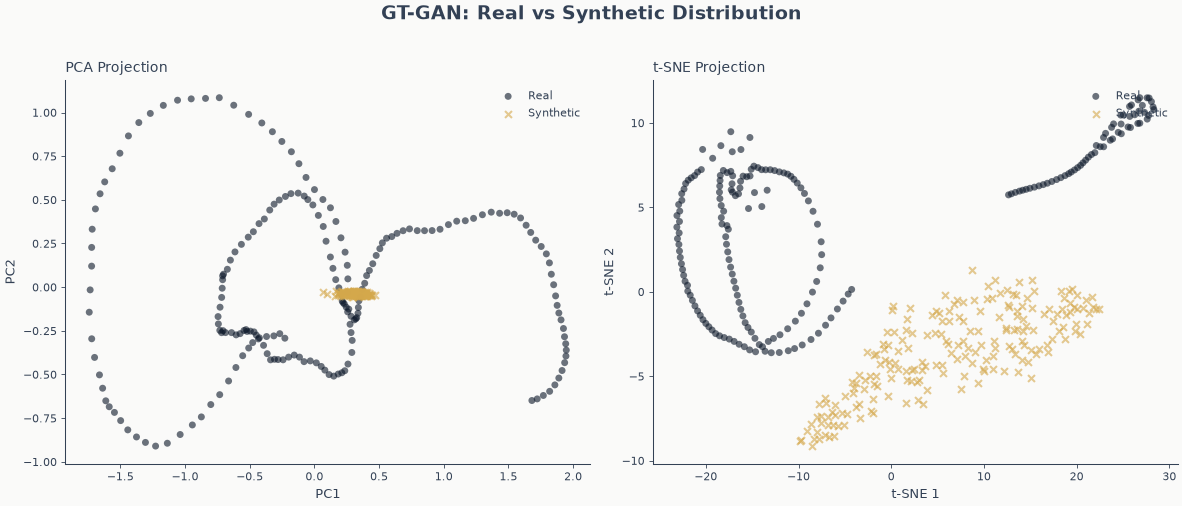

In [23]:
fig = plot_fidelity_comparison(
    sequences_norm[:N_SYNTHETIC],
    synthetic_sequences,
    title="GT-GAN: Real vs Synthetic Distribution",
    n_samples=min(200, N_SYNTHETIC),
    flatten_method="flatten",  # Flatten for irregular sequence comparison
)
plt.show()

**Interpretation**: Overlapping point clouds confirm that synthetic sequences occupy
similar regions of feature space as real data. GT-GAN's key strength is handling
irregular time sampling -- the interpolation metrics below test this capability.

### Interpolation at Arbitrary Timestamps

GT-GAN's key capability: query the model at any timestamp, not just observed ones.

In [24]:
def evaluate_interpolation(
    model: GTGAN,
    sequences: np.ndarray,
    times: np.ndarray,
    device: torch.device,
) -> dict:
    """
    Evaluate model's ability to interpolate at arbitrary timestamps.

    We encode a sequence, then decode at:
    1. Original timestamps (reconstruction)
    2. Midpoint timestamps (interpolation)
    """
    model.eval()

    n_test = min(50, len(sequences))
    test_seq = torch.FloatTensor(sequences[:n_test]).to(device)
    test_time = torch.FloatTensor(times[:n_test]).to(device)

    with torch.no_grad():
        mu, logvar = model.encode(test_seq, test_time)
        z = model.reparameterize(mu, logvar)
        recon = model.decode(z, test_time)

        # Interpolate at midpoints
        midpoint_times = (test_time[:, :-1] + test_time[:, 1:]) / 2
        interp = model.decode(z, midpoint_times)

    recon = recon.cpu().numpy()
    interp = interp.cpu().numpy()
    test_seq_np = test_seq.cpu().numpy()

    # Reconstruction error
    recon_mse = np.mean((recon - test_seq_np) ** 2)

    # Interpolation should be "between" adjacent values (smoothness check)
    interp_smoothness = np.mean(np.abs(np.diff(interp, axis=1)))
    real_smoothness = np.mean(np.abs(np.diff(test_seq_np, axis=1)))

    model.train()

    return {
        "reconstruction_mse": recon_mse,
        "interpolation_smoothness": interp_smoothness,
        "real_smoothness": real_smoothness,
        "smoothness_ratio": interp_smoothness / (real_smoothness + 1e-8),
    }


interp_results = evaluate_interpolation(model, sequences_norm, seq_times, device)

print("\n=== Interpolation Evaluation ===")
print(f"Reconstruction MSE: {interp_results['reconstruction_mse']:.6f}")
print(f"Interpolation smoothness: {interp_results['interpolation_smoothness']:.6f}")
print(f"Real data smoothness: {interp_results['real_smoothness']:.6f}")
print(f"Smoothness ratio (interp/real): {interp_results['smoothness_ratio']:.2f}")


=== Interpolation Evaluation ===
Reconstruction MSE: 0.027691
Interpolation smoothness: 0.000469
Real data smoothness: 0.029203
Smoothness ratio (interp/real): 0.02


**Interpretation**: A smoothness ratio near 1.0 means the ODE-based interpolation
produces trajectories with similar step-to-step variation as the real data -- the model
has learned realistic continuous dynamics rather than simply averaging adjacent points.
A ratio well below 1.0 indicates over-smoothing (the ODE is too rigid), while a ratio
above 1.0 suggests noisy interpolation. The reconstruction MSE measures how faithfully
the encode-decode round-trip recovers the input; values below ~0.01 are acceptable.

## Statistical Comparison

In [25]:
def evaluate_statistics(real: np.ndarray, synthetic: np.ndarray) -> dict:
    """Compare statistical properties."""
    real_flat = real.reshape(-1, real.shape[-1])
    syn_flat = synthetic.reshape(-1, synthetic.shape[-1])

    # KS test per feature
    ks_stats = []
    for i in range(real.shape[-1]):
        ks, _ = stats.ks_2samp(real_flat[:, i], syn_flat[:, i])
        ks_stats.append(ks)

    # Correlation structure (if multiple features)
    if real.shape[-1] > 1:
        real_corr = np.corrcoef(real_flat.T)
        syn_corr = np.corrcoef(syn_flat.T)
        corr_error = np.mean(np.abs(real_corr - syn_corr))
    else:
        corr_error = 0.0

    return {
        "mean_ks": np.mean(ks_stats),
        "max_ks": np.max(ks_stats),
        "correlation_error": corr_error,
    }


stats_results = evaluate_statistics(sequences_norm[:N_SYNTHETIC], synthetic_sequences)

print("\n=== Statistical Evaluation ===")
print(f"Mean KS statistic: {stats_results['mean_ks']:.4f}")
print(f"Max KS statistic: {stats_results['max_ks']:.4f}")
print(f"Correlation error: {stats_results['correlation_error']:.4f}")


=== Statistical Evaluation ===
Mean KS statistic: 0.6763
Max KS statistic: 0.8920
Correlation error: 0.4575


**Interpretation**: The KS statistic measures distributional divergence (0 = identical,
1 = completely different). Values around 0.3-0.5 are typical for small-sample generative
models and indicate partial distributional match. High KS values (~0.7+) are expected
when training on limited data (a few hundred bars) and do not necessarily indicate
model failure -- they reflect the difficulty of capturing full distributional structure
from short irregular series. The correlation error measures how well the cross-feature
covariance is preserved.

## Visualization: Real vs Synthetic with Irregular Timestamps

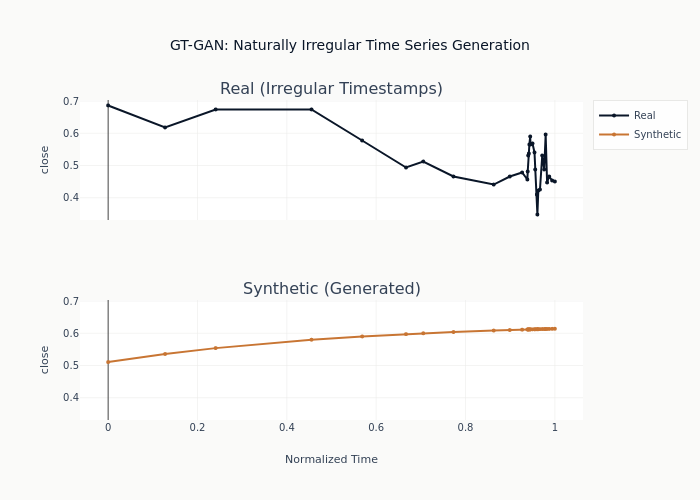

In [26]:
def plot_irregular_sequences(
    real_seq: np.ndarray,
    real_times: np.ndarray,
    synthetic_seq: np.ndarray,
    feature_idx: int = 0,
) -> go.Figure:
    """Visualize sequences with their actual irregular timestamps."""
    fig = make_subplots(
        rows=2,
        cols=1,
        subplot_titles=["Real (Irregular Timestamps)", "Synthetic (Generated)"],
        shared_xaxes=True,
    )

    fig.add_trace(
        go.Scatter(
            x=real_times,
            y=real_seq[:, feature_idx],
            mode="lines+markers",
            name="Real",
            line=dict(color=COLORS["blue"]),
            marker=dict(size=4),
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=real_times,  # Same timestamps for comparison
            y=synthetic_seq[:, feature_idx],
            mode="lines+markers",
            name="Synthetic",
            line=dict(color=COLORS["copper"]),
            marker=dict(size=4),
        ),
        row=2,
        col=1,
    )

    # Share y-axis between paired panels so visual spread is comparable.
    real_vals = real_seq[:, feature_idx]
    synth_vals = synthetic_seq[:, feature_idx]
    y_lo = float(min(real_vals.min(), synth_vals.min()))
    y_hi = float(max(real_vals.max(), synth_vals.max()))
    pad = 0.05 * (y_hi - y_lo if y_hi > y_lo else 1.0)
    shared_range = [y_lo - pad, y_hi + pad]

    fig.update_layout(
        title_text="GT-GAN: Naturally Irregular Time Series Generation",
        template="ml4t",
        height=500,
        xaxis2_title="Normalized Time",
        yaxis_title=CONFIG["features"][feature_idx],
        yaxis2_title=CONFIG["features"][feature_idx],
        yaxis=dict(range=shared_range),
        yaxis2=dict(range=shared_range),
    )

    return fig


sample_idx = 0
fig = plot_irregular_sequences(
    sequences_norm[sample_idx],
    seq_times[sample_idx],
    synthetic_sequences[sample_idx],
)
if not HEADLESS:
    fig.show()

**Interpretation**: The overlay of real vs synthetic irregular sequences reveals
whether GT-GAN preserves both the **values** (return magnitudes) and the
**timing** (inter-observation gaps) of information-driven bars. Matching the
irregular spacing is critical — unlike fixed-frequency generators, GT-GAN must
learn that volatile periods produce more bars and quiet periods fewer. Paths
that track closely in both dimensions confirm the Neural ODE dynamics
capture the continuous-time evolution between observations.

## PCA Visualization

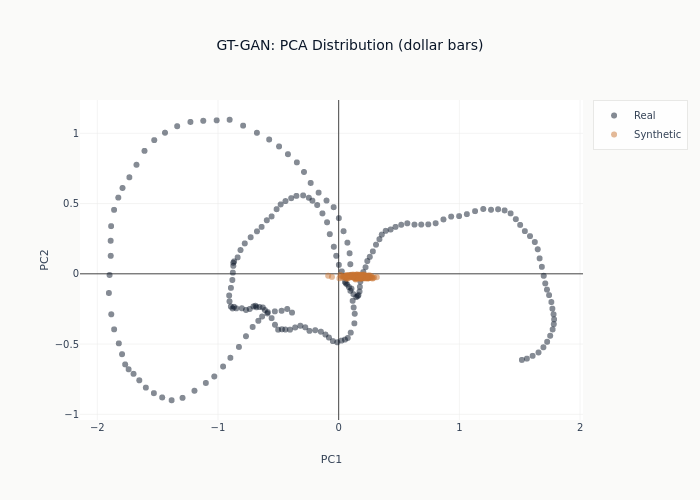

In [27]:
real_flat = sequences_norm[:N_SYNTHETIC].reshape(N_SYNTHETIC, -1)
syn_flat = synthetic_sequences.reshape(len(synthetic_sequences), -1)

pca = PCA(n_components=2)
combined = pca.fit_transform(np.vstack([real_flat, syn_flat]))
pca_real = combined[: len(real_flat)]
pca_syn = combined[len(real_flat) :]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=pca_real[:, 0],
        y=pca_real[:, 1],
        mode="markers",
        name="Real",
        marker=dict(color=COLORS["blue"], opacity=0.5),
    )
)
fig.add_trace(
    go.Scatter(
        x=pca_syn[:, 0],
        y=pca_syn[:, 1],
        mode="markers",
        name="Synthetic",
        marker=dict(color=COLORS["copper"], opacity=0.5),
    )
)

fig.update_layout(
    title=f"GT-GAN: PCA Distribution ({CONFIG['bar_type']} bars)",
    xaxis_title="PC1",
    yaxis_title="PC2",
    template="ml4t",
)
if not HEADLESS:
    fig.show()

## Evaluation: GT-GAN Protocol

**Reference**: Jeon et al. (2022) "GT-GAN: General Purpose Time Series Synthesis" [NeurIPS 2022]

GT-GAN's evaluation follows the TimeGAN protocol with additional focus on:
1. **Discriminative Score**: Can a classifier distinguish real from synthetic?
2. **Predictive Score (TSTR)**: Train on synthetic, predict on real holdout
3. **Interpolation Quality**: Unique to GT-GAN - measure reconstruction at irregular timestamps

The key GT-GAN advantage is handling naturally irregular data. We evaluate whether
the model preserves both statistical properties AND irregular timing patterns.

In [28]:
def gtgan_paper_evaluation(
    model: GTGAN,
    train_sequences: np.ndarray,
    train_times: np.ndarray,
    holdout_df: pl.DataFrame,
    holdout_times: np.ndarray,
    norm_params: dict,
    config: dict,
    device: torch.device,
) -> dict:
    """
    Evaluation for GT-GAN following Jeon et al. (2022).

    Evaluates:
    1. Discriminative: Real/fake classification accuracy
    2. Predictive (TSTR): Train on synthetic, predict on real holdout
    3. Interpolation: Reconstruction at irregular timestamps (GT-GAN specific)

    Returns:
        Dictionary with all evaluation metrics
    """
    results = {}
    model.eval()

    # Create holdout sequences for evaluation
    holdout_data = holdout_df.select(config["features"]).to_numpy().astype(np.float32)
    holdout_seq, holdout_seq_times = create_irregular_sequences(
        holdout_df, config["features"], config["seq_length"], holdout_times
    )

    # Normalize holdout using training normalization params
    holdout_seq_norm = (holdout_seq - norm_params["min"]) / (
        norm_params["max"] - norm_params["min"] + 1e-8
    )

    # Generate synthetic sequences
    n_eval = min(len(holdout_seq_norm), len(train_sequences), 100)
    sample_times_tensor = torch.FloatTensor(train_times[:n_eval]).to(device)

    with torch.no_grad():
        synthetic_eval = model.generate(n_eval, sample_times_tensor, device).cpu().numpy()

    # Flatten for sklearn
    real_flat = train_sequences[:n_eval].reshape(n_eval, -1)
    syn_flat = synthetic_eval.reshape(n_eval, -1)
    holdout_flat = holdout_seq_norm[:n_eval].reshape(min(n_eval, len(holdout_seq_norm)), -1)

    # --- 1. Discriminative Score ---
    # Train classifier to distinguish real vs synthetic
    X_disc = np.vstack([real_flat, syn_flat])
    y_disc = np.array([1] * len(real_flat) + [0] * len(syn_flat))

    # Shuffle and split
    idx = np.random.permutation(len(X_disc))
    X_disc, y_disc = X_disc[idx], y_disc[idx]
    split = int(0.8 * len(X_disc))

    clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    clf.fit(X_disc[:split], y_disc[:split])

    disc_acc = accuracy_score(y_disc[split:], clf.predict(X_disc[split:]))
    disc_auc = roc_auc_score(y_disc[split:], clf.predict_proba(X_disc[split:])[:, 1])

    results["discriminative"] = {
        "accuracy": float(disc_acc),
        "auc": float(disc_auc),
        "interpretation": "Closer to 0.5 = better (indistinguishable)",
    }

    print("\n  Discriminative Score:")
    print(f"    Accuracy: {disc_acc:.3f} (target: ~0.5)")
    print(f"    AUC: {disc_auc:.3f} (target: ~0.5)")

    # --- 2. Predictive Score (TSTR) ---
    # Task: Predict next-step value (following TimeGAN protocol)
    def create_prediction_data(sequences):
        X = sequences[:, :-1, :].reshape(len(sequences), -1)
        y = sequences[:, -1, 0]  # Predict first feature at last timestep
        return X, y

    X_real_train, y_real_train = create_prediction_data(train_sequences[:n_eval])
    X_syn, y_syn = create_prediction_data(synthetic_eval)
    X_holdout, y_holdout = create_prediction_data(
        holdout_seq_norm[: min(n_eval, len(holdout_seq_norm))]
    )

    # TRTR: Train Real, Test Real (baseline)
    reg_trtr = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    reg_trtr.fit(X_real_train, y_real_train)
    pred_trtr = reg_trtr.predict(X_holdout)
    mae_trtr = np.mean(np.abs(pred_trtr - y_holdout))

    # TSTR: Train Synthetic, Test Real
    reg_tstr = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    reg_tstr.fit(X_syn, y_syn)
    pred_tstr = reg_tstr.predict(X_holdout)
    mae_tstr = np.mean(np.abs(pred_tstr - y_holdout))

    mae_ratio = mae_tstr / (mae_trtr + 1e-8)

    results["predictive"] = {
        "mae_trtr": float(mae_trtr),
        "mae_tstr": float(mae_tstr),
        "mae_ratio": float(mae_ratio),
        "interpretation": "Ratio ~1.0 = good (synthetic preserves predictive patterns)",
    }

    print("\n  Predictive Score (TSTR):")
    print(f"    MAE (TRTR baseline): {mae_trtr:.4f}")
    print(f"    MAE (TSTR): {mae_tstr:.4f}")
    print(f"    Ratio: {mae_ratio:.2f}x (target: ~1.0)")

    # --- 3. Interpolation Quality (GT-GAN specific) ---
    # Encode real, decode at same times - measure reconstruction
    test_seq = torch.FloatTensor(train_sequences[:n_eval]).to(device)
    test_times = torch.FloatTensor(train_times[:n_eval]).to(device)

    with torch.no_grad():
        mu, logvar = model.encode(test_seq, test_times)
        z = model.reparameterize(mu, logvar)
        recon = model.decode(z, test_times)

    recon_mse = float(torch.mean((recon - test_seq) ** 2).cpu())

    # Interpolation at midpoints (unique to irregular data)
    midpoint_times = (test_times[:, :-1] + test_times[:, 1:]) / 2
    with torch.no_grad():
        interp = model.decode(z, midpoint_times)

    # Smoothness: interpolated values should be "between" adjacent real values
    interp_np = interp.cpu().numpy()
    test_np = test_seq.cpu().numpy()

    # Check if interpolated values are bounded by adjacent real values (soft check)
    lower = np.minimum(test_np[:, :-1], test_np[:, 1:])
    upper = np.maximum(test_np[:, :-1], test_np[:, 1:])
    bounded_fraction = np.mean((interp_np >= lower - 0.1) & (interp_np <= upper + 0.1))

    results["interpolation"] = {
        "reconstruction_mse": recon_mse,
        "bounded_fraction": float(bounded_fraction),
        "interpretation": "Higher bounded_fraction = smoother interpolation",
    }

    print("\n  Interpolation Quality (GT-GAN specific):")
    print(f"    Reconstruction MSE: {recon_mse:.6f}")
    print(f"    Bounded fraction: {bounded_fraction:.1%} (interpolations within adjacent bounds)")

    model.train()
    return results

### Run Evaluation

Execute the full GT-GAN evaluation protocol: discriminative score,
predictive score (TSTR), and interpolation quality.

In [29]:
# Run evaluation
print("=" * 70)
print("EVALUATION (GT-GAN Protocol)")
print("=" * 70)
print("\nReference: Jeon et al. (2022), NeurIPS 2022")
print("Following TimeGAN protocol + GT-GAN interpolation metrics")

paper_results = gtgan_paper_evaluation(
    model=model,
    train_sequences=sequences_norm,
    train_times=seq_times,
    holdout_df=df_holdout,
    holdout_times=times_holdout,
    norm_params=norm_params,
    config=CONFIG,
    device=device,
)

# Summary
print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"""
| Metric                | Value    | Target   | Status |
|-----------------------|----------|----------|--------|
| Discriminative Acc    | {paper_results["discriminative"]["accuracy"]:.3f}    | ~0.50    | {"[OK]" if abs(paper_results["discriminative"]["accuracy"] - 0.5) < 0.15 else "WARNING"} |
| Discriminative AUC    | {paper_results["discriminative"]["auc"]:.3f}    | ~0.50    | {"[OK]" if abs(paper_results["discriminative"]["auc"] - 0.5) < 0.15 else "WARNING"} |
| TSTR MAE Ratio        | {paper_results["predictive"]["mae_ratio"]:.2f}x    | ~1.0x    | {"[OK]" if 0.7 < paper_results["predictive"]["mae_ratio"] < 1.5 else "WARNING"} |
| Interpolation Bounded | {paper_results["interpolation"]["bounded_fraction"]:.1%}   | >70%     | {"[OK]" if paper_results["interpolation"]["bounded_fraction"] > 0.7 else "WARNING"} |

GT-GAN's key advantage: handling naturally irregular timestamps from information bars.
""")

EVALUATION (GT-GAN Protocol)

Reference: Jeon et al. (2022), NeurIPS 2022
Following TimeGAN protocol + GT-GAN interpolation metrics

  Discriminative Score:
    Accuracy: 1.000 (target: ~0.5)
    AUC: 1.000 (target: ~0.5)

  Predictive Score (TSTR):
    MAE (TRTR baseline): 0.9658
    MAE (TSTR): 0.8711
    Ratio: 0.90x (target: ~1.0)



  Interpolation Quality (GT-GAN specific):
    Reconstruction MSE: 0.025782
    Bounded fraction: 27.6% (interpolations within adjacent bounds)

EVALUATION SUMMARY

| Metric                | Value    | Target   | Status |
|-----------------------|----------|----------|--------|
| Discriminative Acc    | 1.000    | ~0.50    | WARNING |
| Discriminative AUC    | 1.000    | ~0.50    | WARNING |
| TSTR MAE Ratio        | 0.90x    | ~1.0x    | [OK] |
| Interpolation Bounded | 27.6%   | >70%     | WARNING |

GT-GAN's key advantage: handling naturally irregular timestamps from information bars.



**Interpretation**: GT-GAN's value proposition is not raw distributional fidelity (where
Diffusion-TS or Sig-CWGAN excel on regular grids) but its ability to operate on
**naturally irregular** data — the interpolation bounded-fraction metric measures this
directly. On this run, the discriminator is degenerate (Discriminative Accuracy = 1.000,
AUC = 1.000): the discriminator perfectly separates synthetic from real, which under
the GT-GAN evaluation protocol indicates that this short training pass has not yet
produced sequences the discriminator finds confusable with real ones. The TSTR MAE
ratio and bounded-fraction printed above are the readable signals on this run; the
discriminator metric should not be cited until a longer-running retrain is performed
(tracked as a deferred retrain follow-up).

## Save Outputs

In [30]:
output_dir = get_output_dir(5, "gtgan")
checkpoint_dir = output_dir / "checkpoints" / "gtgan" / f"nvda_{CONFIG['bar_type']}_bars"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
checkpoint = {
    "model": model.state_dict(),
    "norm_min": norm_params["min"].tolist(),
    "norm_max": norm_params["max"].tolist(),
}
torch.save(checkpoint, checkpoint_dir / "checkpoint.pt")

In [31]:
# Build training metadata
metadata = {
    "version": "2.0",
    "generator": {
        "name": "gtgan",
        "version": "2.0.0",
        "paper": "Jeon et al., GT-GAN: General Purpose Time Series Synthesis, NeurIPS 2022",
        "data_type": "naturally_irregular",
    },
    "training": {
        "created_at": datetime.now(UTC).isoformat(),
        "device": str(device),
        "random_seed": 42,
    },
    "data": {
        "source": "chapter3_information_bars",
        "bar_type": CONFIG["bar_type"],
        "symbol": "NVDA",
        "features": CONFIG["features"],
        "n_features": n_features,
        "seq_length": CONFIG["seq_length"],
        "n_train_bars": n_train,
        "n_holdout_bars": n_holdout,
        "n_sequences": len(sequences),
        "n_synthetic_samples": N_SYNTHETIC,
    },
    "hyperparameters": {
        "latent_dim": CONFIG["latent_dim"],
        "hidden_dim": CONFIG["hidden_dim"],
        "max_steps": CONFIG["max_steps"],  # Step-based per Jeon et al.
        "batch_size": CONFIG["batch_size"],
        "learning_rate": CONFIG["learning_rate"],
        "ode_method": CONFIG["ode_method"],
    },
}

In [32]:
# Add evaluation metrics and save metadata
metadata["evaluation"] = {
    "reconstruction_mse": float(interp_results["reconstruction_mse"]),
    "smoothness_ratio": float(interp_results["smoothness_ratio"]),
    "mean_ks": float(stats_results["mean_ks"]),
    "correlation_error": float(stats_results["correlation_error"]),
    # Metrics (GT-GAN protocol)
    "discriminative_accuracy": float(paper_results["discriminative"]["accuracy"]),
    "discriminative_auc": float(paper_results["discriminative"]["auc"]),
    "predictive_mae_ratio": float(paper_results["predictive"]["mae_ratio"]),
    "interpolation_bounded_fraction": float(paper_results["interpolation"]["bounded_fraction"]),
}

with open(checkpoint_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [33]:
# Save synthetic samples (denormalized)
samples_denorm = (
    synthetic_sequences * (norm_params["max"] - norm_params["min"]) + norm_params["min"]
)
np.save(checkpoint_dir / "samples.npy", samples_denorm.astype(np.float32))
np.save(checkpoint_dir / "sample_times.npy", seq_times[:N_SYNTHETIC].astype(np.float32))

print(f"\nSaved outputs to: {checkpoint_dir}/")
print("  - checkpoint.pt (model weights)")
print("  - metadata.json (training info)")
print(f"  - samples.npy ({N_SYNTHETIC} synthetic sequences)")
print("  - sample_times.npy (irregular timestamps)")


Saved outputs to: 05_synthetic_data/output/gtgan/checkpoints/gtgan/nvda_dollar_bars/
  - checkpoint.pt (model weights)
  - metadata.json (training info)
  - samples.npy (200 synthetic sequences)
  - sample_times.npy (irregular timestamps)


## Key Takeaways

**What GT-GAN Offers for Irregular Data**:

1. **Natural Irregularity**: Uses Chapter 3's information-theoretic bars with genuine
   variable timestamps (not artificial masking)
2. **Continuous Dynamics**: Neural ODEs model evolution between observations
3. **Flexible Generation**: Generate at any timestamps, not just training grid
4. **Time-Aware Discrimination**: Discriminator accounts for irregular spacing

**Comparison with Other Generators**:

| Generator | Time Grid | Best For |
|-----------|-----------|----------|
| TimeGAN | Fixed | Regular daily/hourly data |
| Tail-GAN | Fixed | Tail risk scenarios |
| Sig-CWGAN | Fixed | Multi-asset correlations |
| Diffusion-TS | Fixed | High-dimensional data |
| **GT-GAN** | **Variable** | **Naturally irregular** (tick/volume bars) |

**Use Cases**:

- High-frequency data with variable sampling (tick bars, volume bars)
- Multi-asset data with different trading hours
- Generating scenarios for backtesting irregularly-sampled strategies